[2026-03-24 18:07:15] === 10銘柄をランダムに選択 ===
選ばれた銘柄:
 - USDC
 - ETH
 - BTC
 - USDT
 - SOL
 - AVAX
 - ADA
 - DOGE
 - XRP
 - BNB
[2026-03-24 18:07:15] Fetching USDC ...
[2026-03-24 18:07:17] Fetching ETH ...
[2026-03-24 18:07:18] Fetching BTC ...
[2026-03-24 18:07:19] Fetching USDT ...
[2026-03-24 18:07:20] Fetching SOL ...
[2026-03-24 18:07:22] Fetching AVAX ...
[2026-03-24 18:07:22] [AVAX] fetch failed: API取得失敗: avalanche-2 / 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/avalanche-2/market_chart?vs_currency=usd&days=90
[2026-03-24 18:07:23] Fetching ADA ...
[2026-03-24 18:07:23] [ADA] fetch failed: API取得失敗: cardano / 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/cardano/market_chart?vs_currency=usd&days=90
[2026-03-24 18:07:24] Fetching DOGE ...
[2026-03-24 18:07:24] [DOGE] fetch failed: API取得失敗: dogecoin / 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/dogecoin/market_chart?v

C:\Users\user\AppData\Local\Temp\ipykernel_8760\3920253473.py:253: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8760\3920253473.py:253: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8760\3920253473.py:253: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8760\3920253473.py:253: UserWarning: Glyph 25943 (\N{CJK UNIFIED IDEOGRAPH-6557}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing from font(s) DejaVu Sans.
  fig.canvas.print

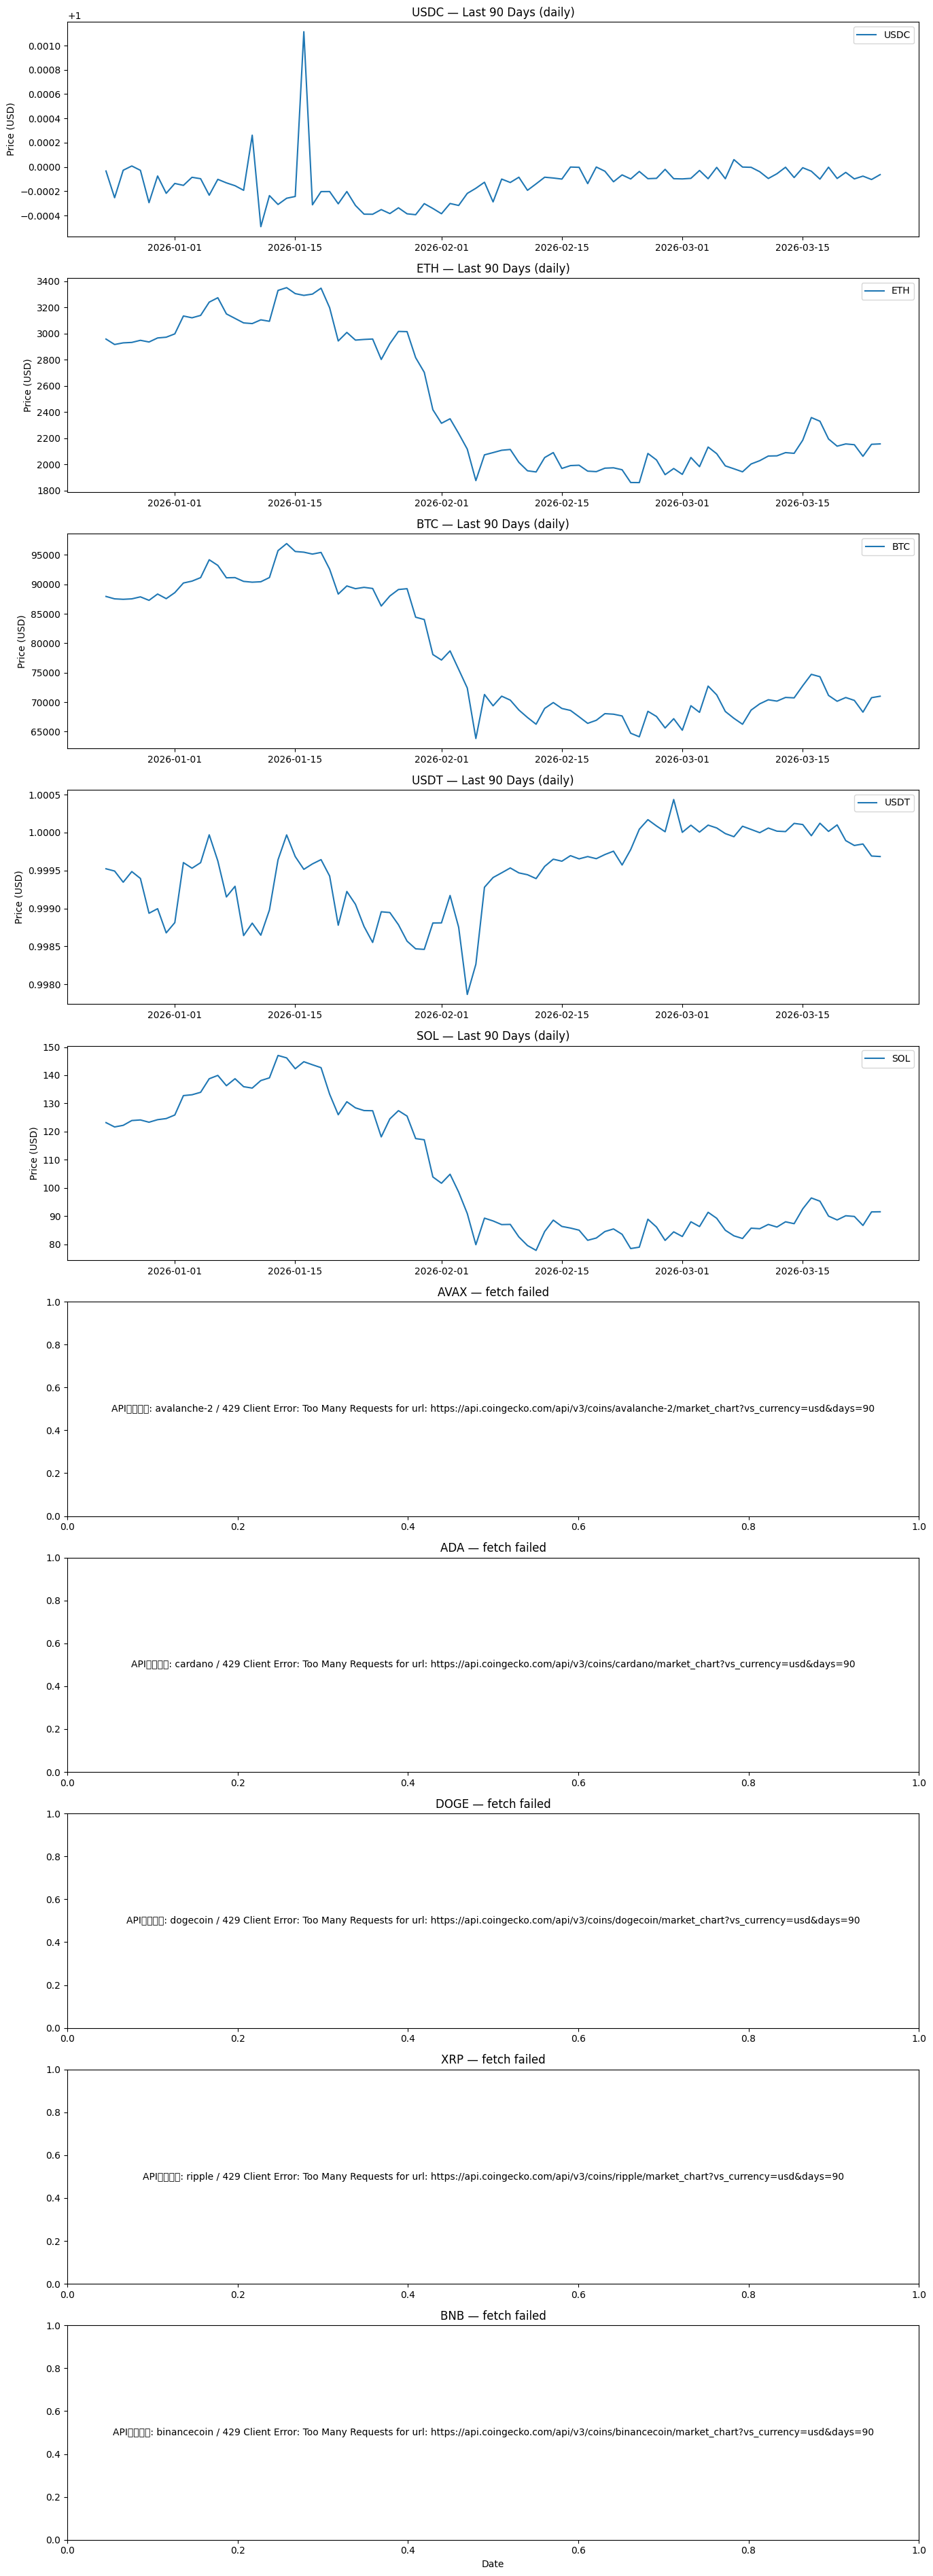

[2026-03-24 18:07:30] === 価格系列の変化点検知 ===
[2026-03-24 18:07:30] Detecting changepoints for USDC ...
[2026-03-24 18:07:30] [USDC] changepoint detection start (n=91)


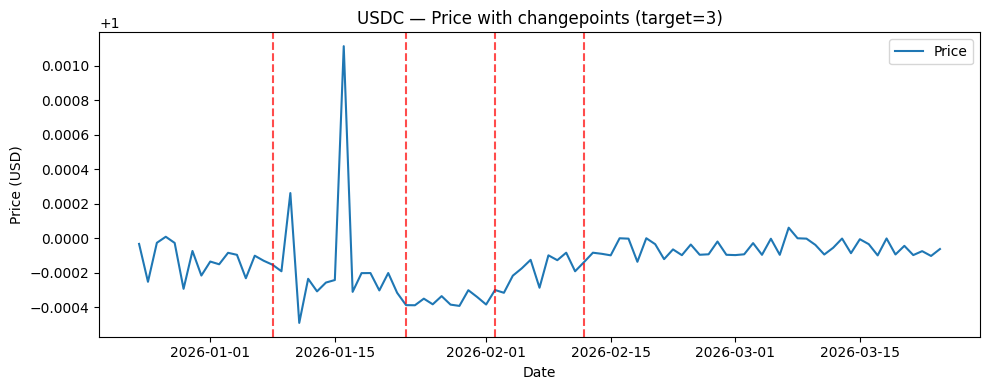

[2026-03-24 18:07:30] [USDC] detected changepoints: [15, 30, 40, 50]
[2026-03-24 18:07:31] Detecting changepoints for ETH ...
[2026-03-24 18:07:31] [ETH] changepoint detection start (n=91)


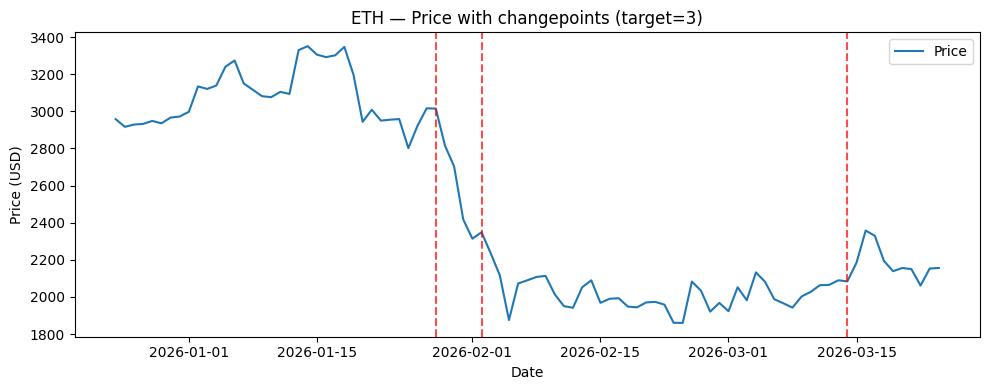

[2026-03-24 18:07:31] [ETH] detected changepoints: [35, 40, 80]
[2026-03-24 18:07:32] Detecting changepoints for BTC ...
[2026-03-24 18:07:32] [BTC] changepoint detection start (n=91)


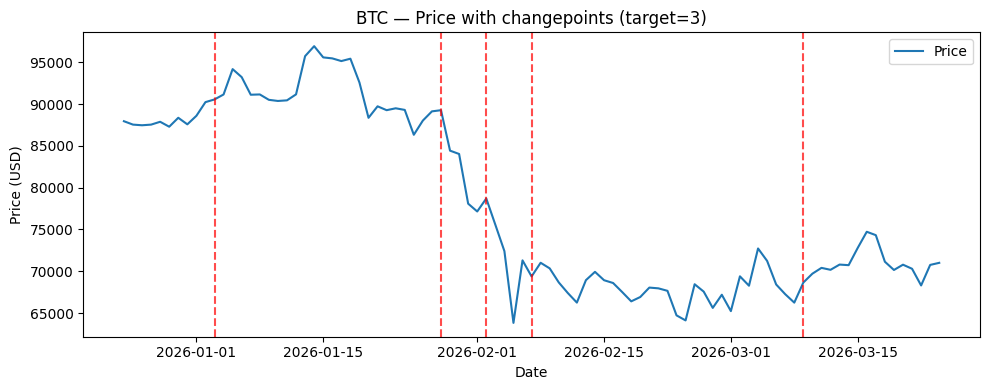

[2026-03-24 18:07:33] [BTC] detected changepoints: [10, 35, 40, 45, 75]
[2026-03-24 18:07:34] Detecting changepoints for USDT ...
[2026-03-24 18:07:34] [USDT] changepoint detection start (n=91)


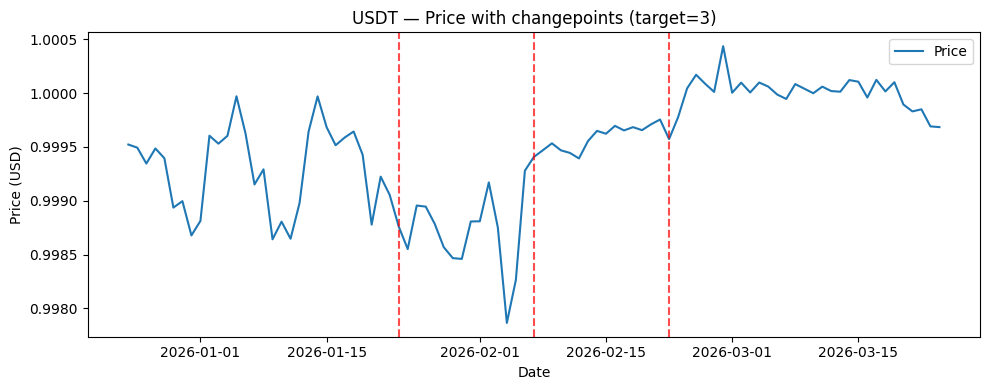

[2026-03-24 18:07:34] [USDT] detected changepoints: [30, 45, 60]
[2026-03-24 18:07:35] Detecting changepoints for SOL ...
[2026-03-24 18:07:35] [SOL] changepoint detection start (n=91)


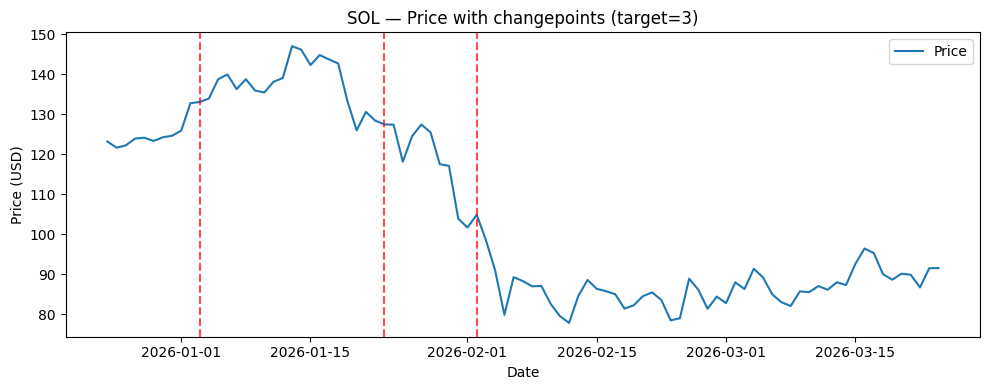

[2026-03-24 18:07:35] [SOL] detected changepoints: [10, 30, 40]

=== 変化点一覧 ===
symbol  cp_no  cp_index cp_timestamp     cp_price
   BTC      1        10   2026-01-03 90546.233688
   BTC      2        35   2026-01-28 89259.320715
   BTC      3        40   2026-02-02 78698.237006
   BTC      4        45   2026-02-07 69375.532279
   BTC      5        75   2026-03-09 68646.004299
   ETH      1        35   2026-01-28  3014.829385
   ETH      2        40   2026-02-02  2348.335609
   ETH      3        80   2026-03-14  2083.960659
   SOL      1        10   2026-01-03   133.079502
   SOL      2        30   2026-01-23   127.466360
   SOL      3        40   2026-02-02   104.862522
  USDC      1        15   2026-01-08     0.999845
  USDC      2        30   2026-01-23     0.999611
  USDC      3        40   2026-02-02     0.999699
  USDC      4        50   2026-02-12     0.999861
  USDT      1        30   2026-01-23     0.998761
  USDT      2        45   2026-02-07     0.999407
  USDT      3        

In [2]:
import random
import time
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
import ruptures as rpt


# ------------------------
# 設定
# ------------------------
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90
BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"

N_SELECT = 10      # ← ランダムに取得する件数

TARGET_BKPS = 3    # ← 目標変化点数
AR_LAGS = 5        # ← ARモデルのラグ
RUN_AR = False     # ← True にすると AR も実行
SLEEP_SEC = 0.8    # ← API呼び出しの待機秒数

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})


def log(msg: str):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ------------------------
# データ取得
# ------------------------
def fetch_market_chart(coin_id: str, days: int = 90, vs: str = "usd") -> pd.DataFrame:
    """
    CoinGecko から market_chart データを取得し、
    日次終値ベースの timestamp, price の DataFrame を返す。
    """
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    try:
        r = session.get(url, params=params, timeout=30)
        r.raise_for_status()
    except requests.RequestException as e:
        raise RuntimeError(f"API取得失敗: {coin_id} / {e}") from e

    data = r.json()
    if "prices" not in data or not data["prices"]:
        raise RuntimeError(f"prices が空です: {coin_id}")

    df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["timestamp", "price"]).sort_values("timestamp")

    # 日次化（その日の最後の価格）
    df = (
        df.set_index("timestamp")
          .resample("1D")
          .last()
          .dropna()
          .reset_index()
    )

    # 正の価格だけ残す
    df = df[df["price"] > 0].copy()

    if len(df) < 10:
        raise RuntimeError(f"有効データが少なすぎます: {coin_id}, n={len(df)}")

    return df


# ------------------------
# 変化点検知（ログ価格, ruptures / PELT）
# ------------------------
def detect_and_plot_changepoints(df: pd.DataFrame, symbol: str, n_bkps: int = 3):
    """
    ログ価格系列に対して変化点検知を行い、
    変化点情報の行リストを返す。
    """
    price = df["price"].astype(float).values
    series = np.log(price).reshape(-1, 1)

    if len(series) < 10:
        log(f"[{symbol}] series too short for changepoint detection, skip")
        return []

    log(f"[{symbol}] changepoint detection start (n={len(series)})")

    algo = rpt.Pelt(model="rbf").fit(series)

    pen = max(np.log(len(series)), 1.0)

    for _ in range(20):
        bkps = algo.predict(pen=pen)
        num = len(bkps) - 1

        if num > n_bkps:
            pen *= 1.5
        elif num < n_bkps:
            pen /= 1.5
        else:
            break

    bkps = algo.predict(pen=pen)

    rows = []
    for i, b in enumerate(bkps[:-1], start=1):
        if 0 < b < len(df):
            ts = df["timestamp"].iloc[b]
            price_at_cp = df["price"].iloc[b]
            rows.append({
                "symbol": symbol,
                "cp_no": i,
                "cp_index": int(b),
                "cp_timestamp": ts,
                "cp_price": float(price_at_cp),
            })

    plt.figure(figsize=(10, 4))
    plt.plot(df["timestamp"], df["price"], label="Price")

    for row in rows:
        plt.axvline(row["cp_timestamp"], color="red", linestyle="--", alpha=0.7)

    plt.title(f"{symbol} — Price with changepoints (target={n_bkps})")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()

    log(f"[{symbol}] detected changepoints: {[r['cp_index'] for r in rows]}")
    return rows


# ------------------------
# ARモデル（価格そのもの）
# ------------------------
def apply_ar_price_in_sample(df: pd.DataFrame, symbol: str, lags: int = 5):
    """
    価格系列に AR(lags) を当てて in-sample fitted を描画。
    """
    series = pd.Series(df["price"].astype(float).values)
    n = len(series)

    if n <= lags + 5:
        log(f"[{symbol}] series too short for AR({lags}), skip")
        return None, None

    try:
        log(f"[{symbol}] fitting AR({lags}) on price (length={n})")
        model = AutoReg(series, lags=lags, old_names=False)
        res = model.fit()
    except Exception as e:
        log(f"[{symbol}] AR fitting failed: {e}")
        return None, None

    fitted = res.fittedvalues
    actual = series[lags:]
    idx = np.arange(lags, n)

    tail = min(50, len(idx))
    idx_tail = idx[-tail:]
    actual_tail = actual.iloc[-tail:]
    fitted_tail = fitted.iloc[-tail:]

    min_len = min(len(idx_tail), len(actual_tail), len(fitted_tail))
    idx_tail = idx_tail[-min_len:]
    actual_tail = actual_tail.iloc[-min_len:]
    fitted_tail = fitted_tail.iloc[-min_len:]

    mse = float(((actual_tail.values - fitted_tail.values) ** 2).mean())
    rmse = float(np.sqrt(mse))
    log(f"[{symbol}] AR({lags}) MSE={mse:.6e}, RMSE={rmse:.6e}")

    plt.figure(figsize=(10, 4))
    plt.plot(idx_tail, actual_tail.values, label="Actual price")
    plt.plot(idx_tail, fitted_tail.values, "--", label="AR fitted price")
    plt.title(f"AR({lags}) on price (in-sample) - {symbol}")
    plt.xlabel("Time index")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse, rmse


# ------------------------
# メイン
# ------------------------
def main():
    if N_SELECT < 1:
        raise ValueError("N_SELECT は 1 以上にしてください。")

    if N_SELECT > len(COINS_POOL):
        raise ValueError("N_SELECT が COINS_POOL の数を超えています。")

    log(f"=== {N_SELECT}銘柄をランダムに選択 ===")

    selected = random.sample(COINS_POOL, N_SELECT)

    print("選ばれた銘柄:")
    for _, sym in selected:
        print(" -", sym)

    dfs = {}

    # ---------- 価格プロット ----------
    fig, axes = plt.subplots(N_SELECT, 1, figsize=(14, 3.8 * N_SELECT), sharex=False)

    if N_SELECT == 1:
        axes = [axes]

    for ax, (coin_id, symbol) in zip(axes, selected):
        try:
            log(f"Fetching {symbol} ...")
            df = fetch_market_chart(coin_id, DAYS, VS)
            dfs[symbol] = df

            ax.plot(df["timestamp"], df["price"], label=symbol)
            ax.set_title(f"{symbol} — Last {DAYS} Days (daily)")
            ax.set_ylabel(f"Price ({VS.upper()})")
            ax.legend()
        except Exception as e:
            log(f"[{symbol}] fetch failed: {e}")
            ax.set_title(f"{symbol} — fetch failed")
            ax.text(0.5, 0.5, str(e), ha="center", va="center", transform=ax.transAxes)

        time.sleep(SLEEP_SEC)

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

    # ---------- 変化点検知 ----------
    log("=== 価格系列の変化点検知 ===")
    all_rows = []

    for symbol, df in dfs.items():
        try:
            log(f"Detecting changepoints for {symbol} ...")
            rows = detect_and_plot_changepoints(df, symbol, n_bkps=TARGET_BKPS)
            all_rows.extend(rows)
        except Exception as e:
            log(f"[{symbol}] changepoint detection failed: {e}")

        time.sleep(SLEEP_SEC)

    if all_rows:
        cp_table = pd.DataFrame(all_rows)
        cp_table["cp_timestamp"] = pd.to_datetime(cp_table["cp_timestamp"]).dt.strftime("%Y-%m-%d")
        cp_table["cp_price"] = cp_table["cp_price"].round(6)
        cp_table = cp_table.sort_values(["symbol", "cp_no"]).reset_index(drop=True)

        print("\n=== 変化点一覧 ===")
        print(cp_table.to_string(index=False))
    else:
        print("\n変化点が検出されませんでした。")

    # ---------- AR ----------
    if RUN_AR:
        log("=== AR モデル適用 ===")
        for symbol, df in dfs.items():
            log(f"Applying AR on PRICE for {symbol} ...")
            apply_ar_price_in_sample(df, symbol, lags=AR_LAGS)
            time.sleep(SLEEP_SEC)


if __name__ == "__main__":
    main()